# Linear-Quadratic Benchmark

This notebook imports saved LQ runs from `results/lq`. It is analysis-only and does not run training.

In [11]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from mfc.visualization import (
    best_runs_by_label,
    gradient_diagnostics,
    load_runs,
    objective_table,
    plot_flow_comparison,
    plot_state_flow,
    plot_validation_rewards,
    runtime_table,
    transport_correction_table,
)

ENV = 'lq'
RESULTS_ROOT = ROOT / 'results'
runs = load_runs(RESULTS_ROOT, env=ENV)
print(f'Loaded {len(runs)} saved runs from {RESULTS_ROOT / ENV}')

Loaded 65 saved runs from /home/adonis/Internship/mfc/results/lq


## Validation Reward

Mean validation reward over training, with one standard deviation across seeds. Exact-flow and particle-flow transport runs are shown separately.

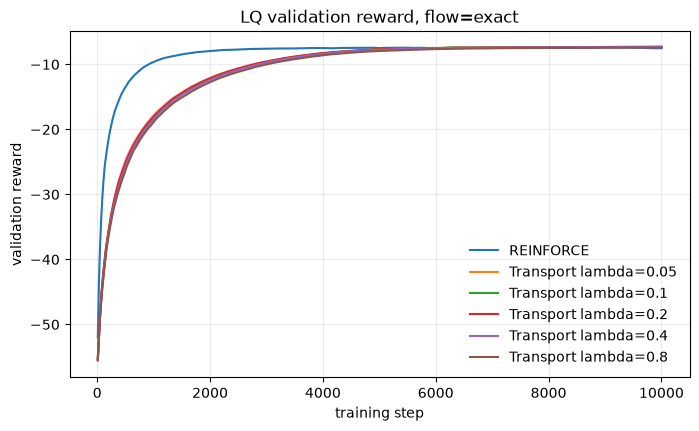

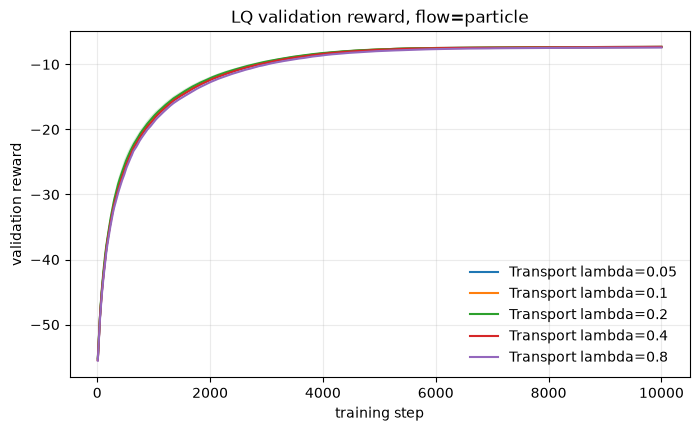

In [12]:
if not runs:
    print('No saved runs yet. Run scripts/run.py before executing the analysis cells.')
else:
    for flow in sorted({run['metadata']['flow'] for run in runs}):
        fig, ax = plt.subplots(figsize=(8, 4.5))
        try:
            plot_validation_rewards(runs, env=ENV, horizon=20, flow=flow, ax=ax)
            ax.set_title(f'LQ validation reward, flow={flow}')
            plt.show()
        except ValueError as exc:
            plt.close(fig)
            print(exc)

## Mean and Variance Flow

Population mean and variance induced by the best saved policy for each algorithm, perturbation, and flow setting.

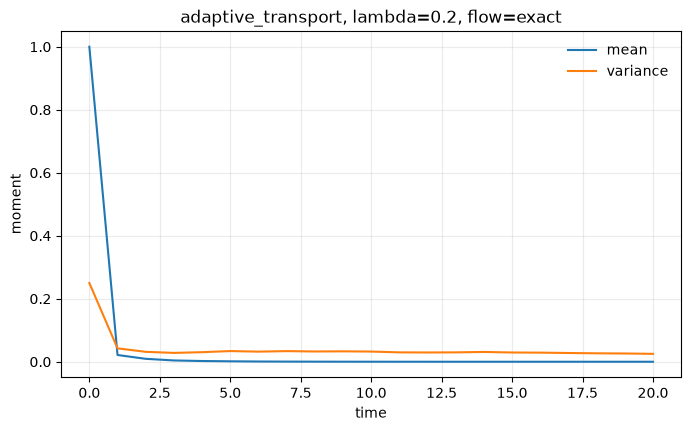

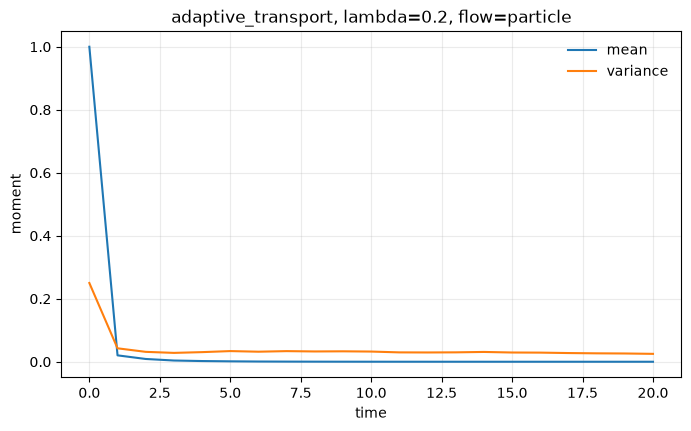

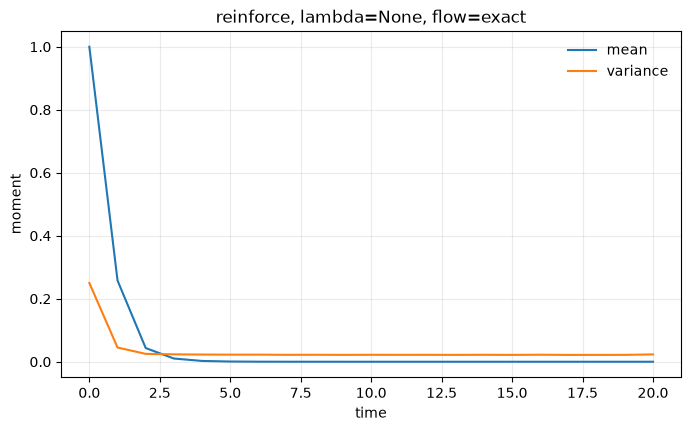

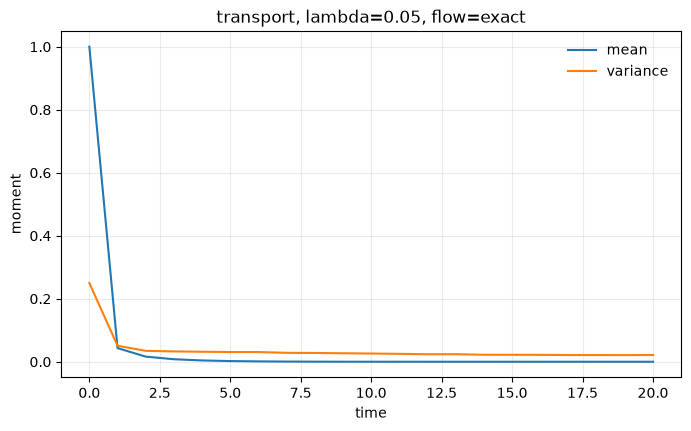

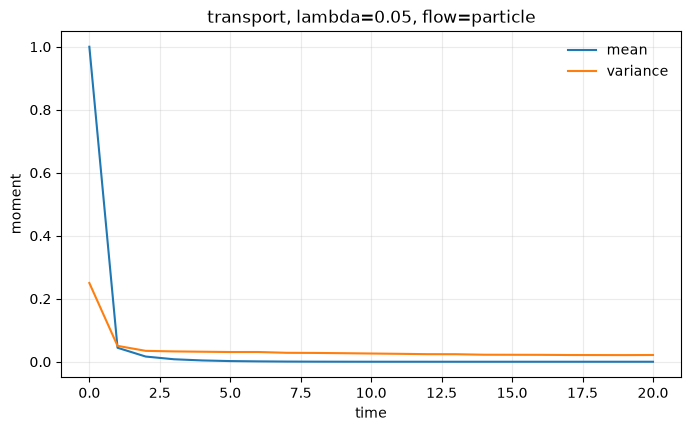

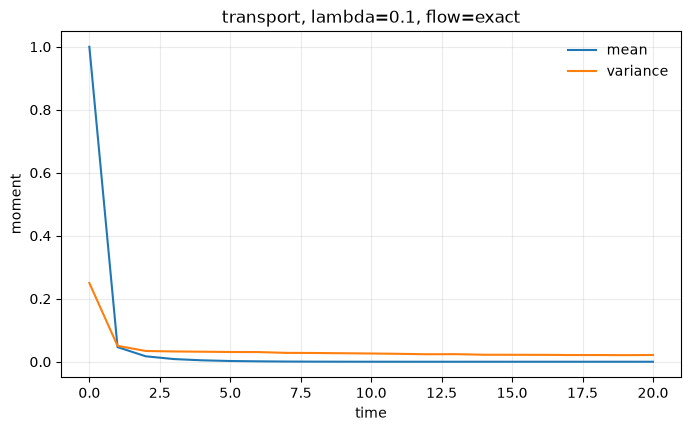

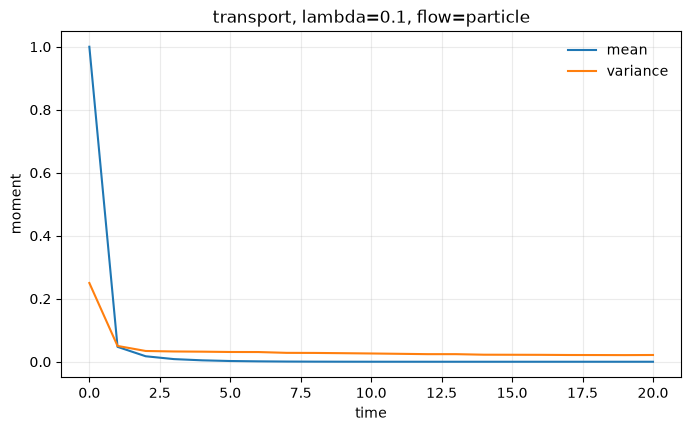

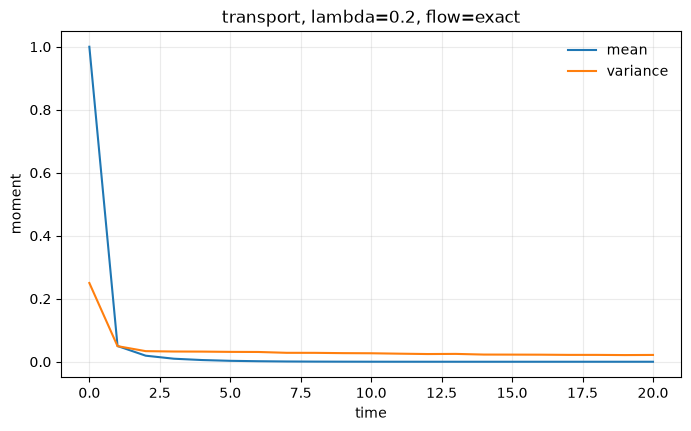

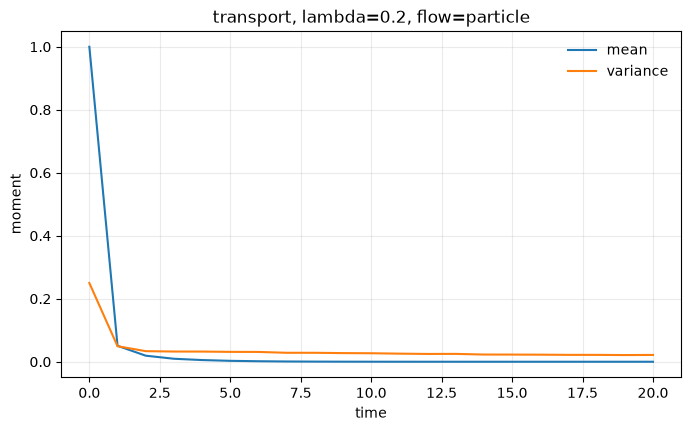

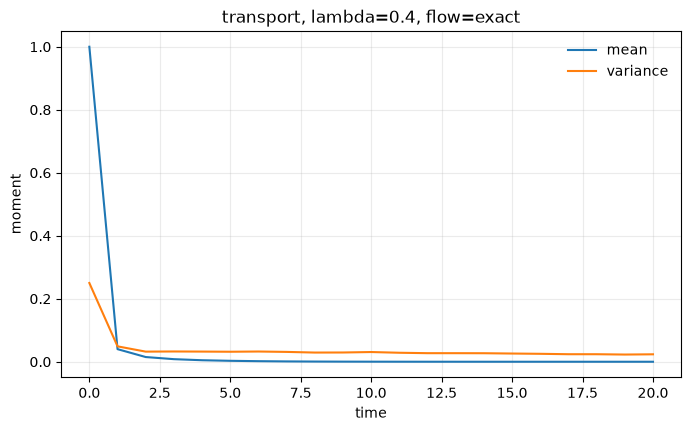

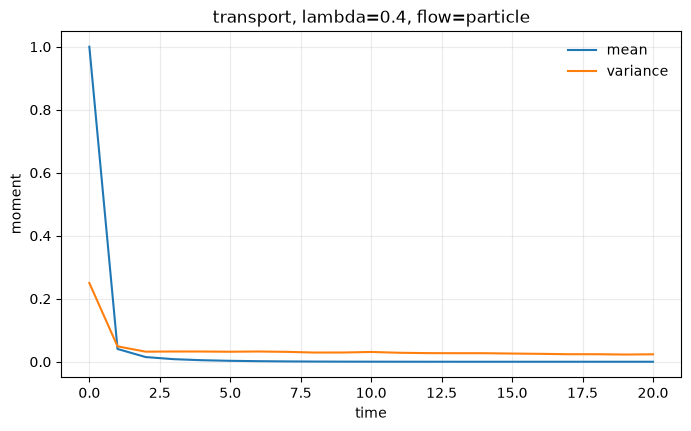

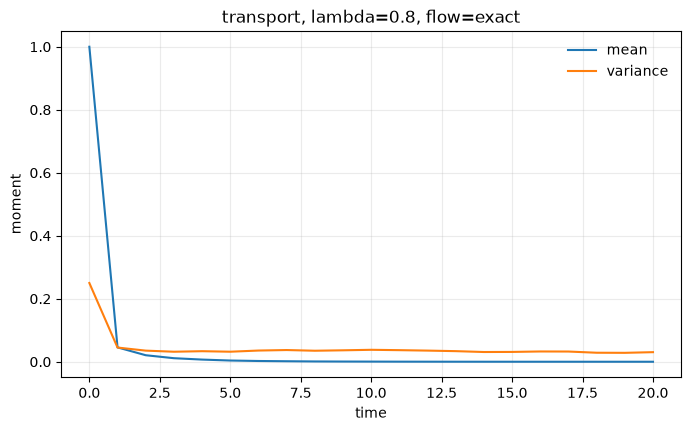

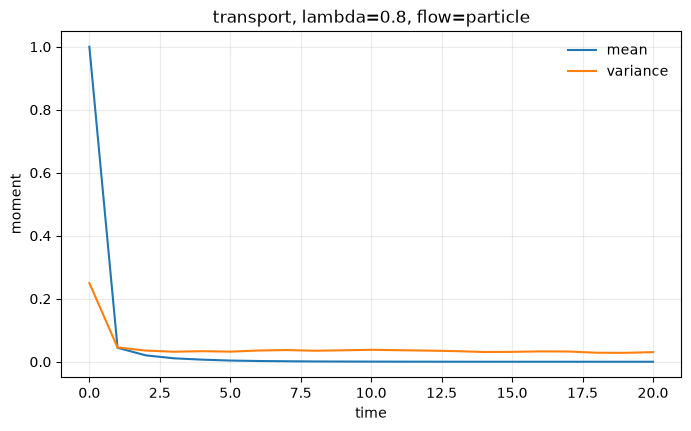

In [13]:
for run in best_runs_by_label(runs):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    plot_state_flow(run, ax=ax)
    meta = run['metadata']
    ax.set_title(f"{meta['algorithm']}, lambda={meta['perturbation']}, flow={meta['flow']}")
    plt.show()

## Exact vs Particle Flow

Transport validation curves split by exact and particle flow. This is the main comparison for whether estimating the population flow changes training behavior.

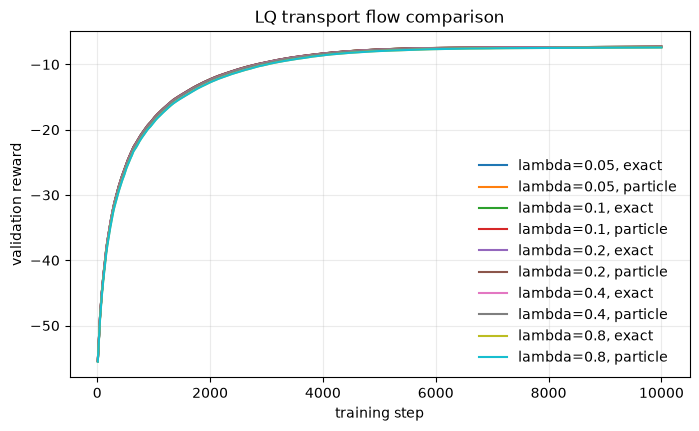

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.5))
try:
    plot_flow_comparison(runs, env=ENV, horizon=20, ax=ax)
    ax.set_title('LQ transport flow comparison')
    plt.show()
except ValueError as exc:
    plt.close(fig)
    print(exc)

## Objective Table: J vs J^lambda

Closed-form objective values at the learned policy. `J0_star` is included when the environment exposes the analytical optimizer.

In [15]:
display(objective_table(runs))

,env,label,flow,horizon,seed,validation_reward,objective_convention,J0,Jlambda,J0_star,Jlambda_star
0,lq,Transport lambda=0.2,exact,20,0,-7.361252,cost,7.361252,11.776643,7.223777,11.628485
1,lq,Transport lambda=0.2,exact,20,1,-7.365832,cost,7.365832,11.782120,7.223777,11.628485
2,lq,Transport lambda=0.2,exact,20,2,-7.355663,cost,7.355663,11.772065,7.223777,11.628485
3,lq,Transport lambda=0.2,exact,20,3,-7.368071,cost,7.368071,11.786097,7.223777,11.628485
4,lq,Transport lambda=0.2,exact,20,4,-7.367892,cost,7.367892,11.785703,7.223777,11.628485
...,...,...,...,...,...,...,...,...,...,...,...
60,lq,Transport lambda=0.8,particle,20,0,-7.414613,cost,7.414613,78.082070,7.223777,77.653669
61,lq,Transport lambda=0.8,particle,20,1,-7.408926,cost,7.408926,78.106914,7.223777,77.653669
62,lq,Transport lambda=0.8,particle,20,2,-7.423184,cost,7.423184,78.094233,7.223777,77.653669
63,lq,Transport lambda=0.8,particle,20,3,-7.414896,cost,7.414896,78.048245,7.223777,77.653669


## Transport Gradient Diagnostics

Optional Monte Carlo check of bias, MSE, cosine similarity, and perturbation bias against the exact LQ gradient oracle. Leave disabled for ordinary report viewing.

In [16]:
RUN_GRADIENT_DIAGNOSTICS = True
N_REPLICATIONS = 20

if RUN_GRADIENT_DIAGNOSTICS:
    tables = []
    for run in runs:
        try:
            tables.append(gradient_diagnostics(run, n_replications=N_REPLICATIONS))
        except ValueError:
            pass
    display(pd.concat(tables, ignore_index=True) if tables else pd.DataFrame())
else:
    print('Set RUN_GRADIENT_DIAGNOSTICS = True to recompute gradient bias/MSE diagnostics.')

,env,label,flow,horizon,lambda,n_parameters,diagnostic_n_particles,n_replications,bias_norm,estimate_std,...,bias_z,bias_z_null_rms,bias_chi2_stat,bias_chi2_df,bias_chi2_pvalue,mse,cosine_similarity,exact_gradient_norm,estimate_gradient_norm_mean,perturbation_bias_norm
0,lq,Transport lambda=0.05,exact,20,0.05,40,201,20,0.261281,1.182264,...,0.988345,1.0,39.073003,40,0.511841,0.034903,0.848182,0.123636,1.114362,0.002969
1,lq,Transport lambda=0.05,exact,20,0.05,40,201,20,0.284684,1.223446,...,1.040621,1.0,43.315703,40,0.331761,0.037576,0.230365,0.129356,1.155419,0.002902
2,lq,Transport lambda=0.05,exact,20,0.05,40,201,20,0.261192,1.194332,...,0.978027,1.0,38.261439,40,0.548698,0.035583,0.796496,0.115235,1.125868,0.003114
3,lq,Transport lambda=0.05,exact,20,0.05,40,201,20,0.254747,1.199702,...,0.949623,1.0,36.071318,40,0.647751,0.035805,0.640310,0.096874,1.126024,0.002857
4,lq,Transport lambda=0.05,exact,20,0.05,40,201,20,0.263081,1.171343,...,1.004432,1.0,40.355380,40,0.454546,0.034316,0.821605,0.116149,1.106100,0.002941
5,lq,Transport lambda=0.05,particle,20,0.05,40,201,20,0.292875,1.240101,...,1.056186,1.0,44.621158,40,0.283681,0.038668,0.833100,0.124215,1.170901,0.002967
6,lq,Transport lambda=0.05,particle,20,0.05,40,201,20,0.316421,1.279397,...,1.106050,1.0,48.933827,40,0.157159,0.041378,0.122905,0.139080,1.201121,0.002910
7,lq,Transport lambda=0.05,particle,20,0.05,40,201,20,0.297001,1.253118,...,1.059939,1.0,44.938860,40,0.272639,0.039500,0.750860,0.112865,1.186709,0.003133
8,lq,Transport lambda=0.05,particle,20,0.05,40,201,20,0.285240,1.256546,...,1.015188,1.0,41.224305,40,0.416855,0.039533,0.550872,0.096276,1.182841,0.002857
9,lq,Transport lambda=0.05,particle,20,0.05,40,201,20,0.312085,1.228586,...,1.136010,1.0,51.620729,40,0.103083,0.038284,0.771303,0.112342,1.168088,0.002938


## Missing Mean-Field Correction Term

Optional diagnostic comparing the full transport gradient with the policy-only term. The difference is the mean-field correction that classical REINFORCE drops.

In [17]:
RUN_CORRECTION_DIAGNOSTIC = True

if RUN_CORRECTION_DIAGNOSTIC:
    tables = []
    for run in runs:
        try:
            tables.append(transport_correction_table(run, n_replications=N_REPLICATIONS))
        except ValueError:
            pass
    display(pd.concat(tables, ignore_index=True) if tables else pd.DataFrame())
else:
    print('Set RUN_CORRECTION_DIAGNOSTIC = True to estimate the missing correction term.')

KeyboardInterrupt: 

## Runtime Table

Average elapsed time and estimated simulator budget for each algorithm configuration.

In [18]:
display(runtime_table(runs))

,env,algorithm,perturbation,horizon,flow,setup_seconds_mean,setup_seconds_std,train_step_seconds_mean,train_step_seconds_std,validation_seconds_mean,validation_seconds_std,elapsed_seconds_mean,elapsed_seconds_std,seconds_per_step_mean,wall_seconds_per_step_mean,validation_seconds_per_call_mean,simulator_budget_mean,n_runs
0,lq,adaptive_transport,0.20,20,exact,8.456831,2.165135,1092.005042,11.362819,3.973445,0.086426,1104.473868,10.710445,0.109201,0.110447,0.003973,4406.4,5
1,lq,adaptive_transport,0.20,20,particle,8.932744,1.498820,1106.968233,3.595749,3.956330,0.050802,1119.898295,3.416365,0.110697,0.111990,0.003956,8406.4,5
2,lq,reinforce,NaN,20,exact,7.551700,0.220992,101.018401,0.751301,4.052524,0.022342,112.665328,0.856109,0.010102,0.011267,0.004053,4420.0,5
3,lq,transport,0.05,20,exact,7.597850,0.304540,1035.122238,5.315786,4.077421,0.077699,1046.836957,5.423298,0.103512,0.104684,0.004077,4420.0,5
4,lq,transport,0.05,20,particle,9.505653,2.766477,1020.020039,3.125045,3.912504,0.062921,1033.471739,2.339390,0.102002,0.103347,0.003913,8420.0,5
5,lq,transport,0.10,20,exact,8.342749,1.792134,1046.643440,10.257378,4.110122,0.112085,1059.133878,9.844446,0.104664,0.105913,0.004110,4420.0,5
6,lq,transport,0.10,20,particle,7.738312,0.275806,1019.949455,4.248737,3.918153,0.119937,1031.642926,4.312788,0.101995,0.103164,0.003918,8420.0,5
7,lq,transport,0.20,20,exact,8.164127,1.852873,1054.068473,11.153368,4.159706,0.083264,1066.428310,12.791630,0.105407,0.106643,0.004160,4420.0,5
8,lq,transport,0.20,20,particle,9.611130,2.101046,1017.033288,7.704545,3.954609,0.031213,1030.633380,7.977571,0.101703,0.103063,0.003955,8420.0,5
9,lq,transport,0.40,20,exact,7.784823,0.257625,1057.117936,4.071459,4.160390,0.071336,1069.101506,3.932842,0.105712,0.106910,0.004160,4420.0,5
